In this notebook, I will explore the steps involved in creating PCA, tsne and umap techniques. Also, contains the scripts used to find cosine similarity matrix.

Dataset - **Occupation ethnic age gender.xlsx** from the original data folder.

This section consists of two subsections, dimensionality reduction and cosine similarity.

In [2]:
#necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.metrics.pairwise import cosine_similarity

In [3]:
#directory path
original_data_path = os.path.join(os.getcwd(), 'original data')
transformed_data_path = os.path.join(os.getcwd(), 'transformed data')

In [4]:
#store the current directory as pwd
pwd = os.getcwd()

In [5]:
os.chdir(original_data_path) #change the directory
df = pd.read_excel("dimen red and cosine.xlsx") #load the dataset
os.chdir(pwd) #change the directory back to pwd

# 1. Dimensionality reduction

In [6]:
df1 = df.copy()
df1.head()

,Local district,"Managers, directors and senior officials",Professional occupations,Associate professional and technical occupations,Administrative and secretarial occupations,Skilled trades occupations,"Caring, leisure and other service occupations",Sales and customer service occupations,"Process, plant and machine operatives",Elementary occupations,Gender
0,Darlington,2922,3590,3464,1345,5160,825,1731,3223,3114,Male
1,County Durham,12507,15136,14277,5442,25924,4369,5994,20433,14912,Male
2,Hartlepool,1832,2226,2434,678,4748,682,963,3570,2448,Male
3,Middlesbrough,2406,3244,3124,1236,5796,1251,2054,5008,4163,Male
4,Northumberland,9632,10526,10131,3371,17020,2999,3831,10301,8568,Male


In [7]:
X = df1.iloc[:, 1:-1].values
y = df1.iloc[:,-1].values
x = StandardScaler().fit_transform(X)

In [8]:
X_pca = PCA(n_components=2).fit_transform(x)
X_tsne = TSNE().fit_transform(x)
X_umap = UMAP(n_neighbors=15,min_dist=0.1,metric='correlation').fit_transform(x)

In [9]:
data = np.concatenate([X_pca, X_tsne, X_umap], axis=1)

In [10]:
resultdf1 = pd.DataFrame(data = data, columns =['pca1', 'pca2','tsne1',
                                               'tsne2', 'umap1', 'umap2'])

In [11]:
resultdf1 = pd.concat([resultdf1, pd.Series(y)],axis=1)

In [12]:
resultdf1.head()

,pca1,pca2,tsne1,tsne2,umap1,umap2,0
0,-1.240597,-0.892549,16.127314,18.115376,-2.815368,9.994505,Male
1,7.105310,-4.935253,35.394176,-8.768640,-3.416886,9.173649,Male
2,-1.844443,-0.964928,9.311732,25.730909,-2.874987,11.041076,Male
3,-1.001873,-1.074892,26.828926,19.501223,-3.677809,10.828033,Male
4,3.332743,-2.986293,33.525295,-5.070579,-2.477665,7.973019,Male


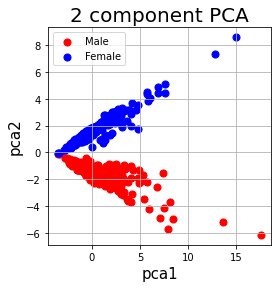

In [13]:
#PCA
fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('pca1', fontsize = 15)
ax.set_ylabel('pca2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
labels = ['Male', 'Female']
colours = ['r', 'b']

for label, colour in zip(labels, colours):
    temp = resultdf1[0] == label
    ax.scatter(resultdf1.loc[temp, 'pca1'],resultdf1.loc[temp, 'pca2'],
              c = colour, s=50)
    
ax.legend(labels)
ax.grid()

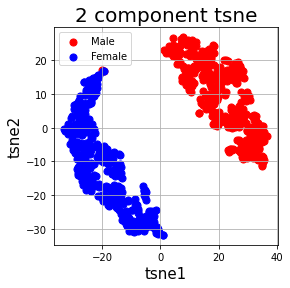

In [16]:
#TSNE
fig1 = plt.figure(figsize = (4,4))
ax1 = fig1.add_subplot(1,1,1) 
ax1.set_xlabel('tsne1', fontsize = 15)
ax1.set_ylabel('tsne2', fontsize = 15)
ax1.set_title('2 component tsne', fontsize = 20)
labels = ['Male', 'Female']
colours = ['r', 'b']

for label, colour in zip(labels, colours):
    temp = resultdf1[0] == label
    ax1.scatter(resultdf1.loc[temp, 'tsne1'],resultdf1.loc[temp, 'tsne2'],
              c = colour, s=50)
    
ax1.legend(labels)
ax1.grid()

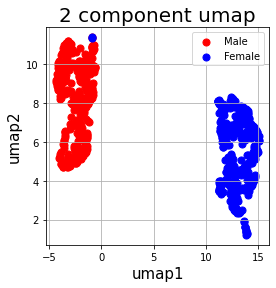

In [15]:
#UMAP
fig2 = plt.figure(figsize = (4,4))
ax2 = fig2.add_subplot(1,1,1) 
ax2.set_xlabel('umap1', fontsize = 15)
ax2.set_ylabel('umap2', fontsize = 15)
ax2.set_title('2 component umap', fontsize = 20)
labels = ['Male', 'Female']
colours = ['r', 'b']

for label, colour in zip(labels, colours):
    temp = resultdf1[0] == label
    ax2.scatter(resultdf1.loc[temp, 'umap1'],resultdf1.loc[temp, 'umap2'],
              c = colour, s=50)
    
ax2.legend(labels)
ax2.grid()

# 2. Cosine Similarity

In [137]:
df2 = df.copy()

In [138]:
df2.head()

,Local district,"Managers, directors and senior officials",Professional occupations,Associate professional and technical occupations,Administrative and secretarial occupations,Skilled trades occupations,"Caring, leisure and other service occupations",Sales and customer service occupations,"Process, plant and machine operatives",Elementary occupations,Gender
0,Darlington,2922,3590,3464,1345,5160,825,1731,3223,3114,Male
1,County Durham,12507,15136,14277,5442,25924,4369,5994,20433,14912,Male
2,Hartlepool,1832,2226,2434,678,4748,682,963,3570,2448,Male
3,Middlesbrough,2406,3244,3124,1236,5796,1251,2054,5008,4163,Male
4,Northumberland,9632,10526,10131,3371,17020,2999,3831,10301,8568,Male


In [144]:
def cosine_similar(dataframe, gender):
    temp = dataframe[dataframe["Gender"] == gender]
    temp.drop("Gender", inplace=True, axis=1)
    temp = temp.set_index("Local district")
    answer = cosine_similarity(temp.values)
    return pd.DataFrame(answer, columns=temp.index.values, index=temp.index).reset_index()

In [145]:
cosine_similar(dataframe = df2, gender="Female")

E:\Anaconda\lib\site-packages\pandas\core\frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,Local district,Darlington,County Durham,Hartlepool,Middlesbrough,Northumberland,Redcar and Cleveland,Stockton-on-Tees,Gateshead,Newcastle upon Tyne,...,Bridgend,Vale of Glamorgan,Cardiff,Rhondda Cynon Taff,Merthyr Tydfil,Caerphilly,Blaenau Gwent,Torfaen,Monmouthshire,Newport
0,Darlington,1.000000,0.997231,0.992383,0.984629,0.995144,0.991284,0.998409,0.998420,0.983592,...,0.996851,0.986292,0.972495,0.991009,0.990731,0.992843,0.970785,0.992769,0.971273,0.998214
1,County Durham,0.997231,1.000000,0.993730,0.989808,0.997386,0.994520,0.998829,0.995507,0.985138,...,0.999149,0.986213,0.971677,0.996841,0.995779,0.996314,0.981338,0.995988,0.976470,0.999078
2,Hartlepool,0.992383,0.993730,1.000000,0.997393,0.987587,0.998538,0.992290,0.987471,0.973029,...,0.993684,0.969676,0.949535,0.994702,0.995737,0.989711,0.989659,0.994044,0.954368,0.991187
3,Middlesbrough,0.984629,0.989808,0.997393,1.000000,0.981518,0.996266,0.987544,0.979714,0.973207,...,0.989704,0.960344,0.944313,0.993281,0.996880,0.984338,0.992909,0.988942,0.951411,0.985924
4,Northumberland,0.995144,0.997386,0.987587,0.981518,1.000000,0.990968,0.996143,0.992348,0.982256,...,0.997326,0.993625,0.975495,0.994055,0.987563,0.992123,0.973174,0.992336,0.985024,0.996999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,Caerphilly,0.992843,0.996314,0.989711,0.984338,0.992123,0.991353,0.993415,0.992679,0.970900,...,0.992874,0.978514,0.955902,0.994035,0.991624,1.000000,0.980124,0.998484,0.961040,0.995596
344,Blaenau Gwent,0.970785,0.981338,0.989659,0.992909,0.973174,0.990727,0.974216,0.962752,0.950658,...,0.980971,0.948256,0.921096,0.989836,0.988535,0.980124,1.000000,0.986133,0.938793,0.973415
345,Torfaen,0.992769,0.995988,0.994044,0.988942,0.992336,0.996145,0.992817,0.990144,0.968030,...,0.993845,0.978324,0.951666,0.996794,0.992285,0.998484,0.986133,1.000000,0.958857,0.994223
346,Monmouthshire,0.971273,0.976470,0.954368,0.951411,0.985024,0.960251,0.977135,0.969118,0.983172,...,0.979643,0.989536,0.988912,0.970323,0.962422,0.961040,0.938793,0.958857,1.000000,0.976505
